In [1]:
import json
import cv2
import matplotlib.pyplot as plt
import os

os.chdir('..')

from src.utils.annotations import transform_bbox

In [1]:
# with open('data/label-studio-annotations/runda_1.json') as f:
#     data = json.load(f)


# with open('data/label-studio-annotations/runda_1_ind.json', 'w') as f:
#     json.dump(data, f, indent=4)  

In [2]:
from src.utils.const import BallColor

In [3]:
for color in BallColor:
    print(color)

blue
yellow
green
brown
pink
red
cue
black


In [4]:
# [
#     {
#         "image": {
#             "name": "jakis tam",
#             "width": 1168,
#             "height": 918
#         },
#         "balls": [
#             {
#                 "color": "cue",
#                 "bboxes": [
#                     {
#                         'x': 45.067881604696666,
#                         'y': 66.26984126984127,
#                         'width': 2.495107632093941,
#                         'height': 3.7698412698412724
#                     },
#                     {
#                         'x': 46.62732387475537,
#                         'y': 65.47619047619047,
#                         'width': 2.4951076320939367,
#                         'height': 3.3730158730158806
#                     }
#                 ]
#             }
#         ]
#     }
# ]

##### testowanie BallAnnotationCollection

In [ ]:
from src.utils.annotations import transform_bbox

In [ ]:
from src.utils.annotations import BallAnnotationCollection

In [ ]:
bac = BallAnnotationCollection('data/label-studio-annotations')

In [ ]:
bac.save('data/runda1_cleand.json')

Data saved successfully


In [ ]:
bac.validate()

Wszystkie oznaczenia są ok!


In [ ]:
loaded_bac = BallAnnotationCollection.from_cleans('data/runda1_cleand.json')

In [ ]:
loaded_bac.validate()

Wszystkie oznaczenia są ok!


In [ ]:
loaded_bac.cleaned_annotations

[ImageBallAnnotation(image=ImageMetaData(name='pic_01_02_01.png', width=1168, height=918, source_file_name='runda_1'), balls=[Ball(color=<BallColor.BLUE: 'blue'>, bboxes=[BBox(x=47.5629892367906, y=47.02380952380952, width=2.8069960861056704, height=3.174603174603177)]), Ball(color=<BallColor.YELLOW: 'yellow'>, bboxes=[BBox(x=37.11472602739725, y=30.357142857142854, width=3.1188845401174206, height=3.1746031746031775)]), Ball(color=<BallColor.GREEN: 'green'>, bboxes=[BBox(x=58.47908512720156, y=30.357142857142854, width=2.183219178082183, height=2.9761904761904745)]), Ball(color=<BallColor.BROWN: 'brown'>, bboxes=[BBox(x=48.03082191780821, y=30.357142857142854, width=2.4951076320939265, height=3.174603174603177)]), Ball(color=<BallColor.PINK: 'pink'>, bboxes=[BBox(x=47.5629892367906, y=63.29365079365079, width=2.80699608610567, height=2.3809523809523725)]), Ball(color=<BallColor.RED: 'red'>, bboxes=[BBox(x=58.01125244618394, y=68.84920634920634, width=2.806996086105684, height=3.571428

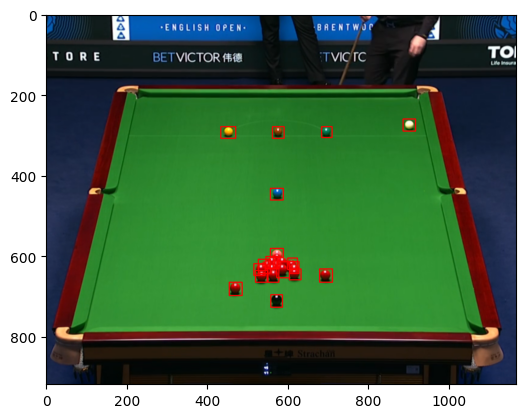

In [ ]:
picname = 'pic_01_02_01.png'
ann = loaded_bac.filter_by_image(picname)
img = cv2.imread(f'data/pics/{picname}')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
out_img = BallAnnotationCollection.display_on_image(ann, img)
plt.imshow(out_img)

##### testowanie PlayfieldAnnotationCollection

In [2]:
from src.utils.annotations import PlayfieldAnnotationCollection

In [3]:
pac = PlayfieldAnnotationCollection.from_raw_dir('data/label-studio-annotations')

In [6]:
# pac.cleaned_annotations

In [4]:
pac.validate()

Wszystkie oznaczenia są ok!
Nie ma duplikatow


In [6]:
pac.filter_by_image('pic_05_05_02.png')

ImagePlayfieldAnnotation(image=ImageMetaData(name='pic_05_05_02.png', width=1063, height=700, source_file_name='05_05_02_poprawione'), points=[[22.836132794266554, 17.23009814612868], [75.40232526408766, 16.68484187568157], [84.73785124916519, 83.31515812431843], [13.213359855802029, 82.87895310796074]])

In [7]:
pac.save('data/playfield_gt.json')

Data saved successfully


In [19]:
leaded_clean = PlayfieldAnnotationCollection.from_clean_file('data/playfield_gt.json')

In [20]:
leaded_clean.cleaned_annotations
leaded_clean.validate()

Wszystkie oznaczenia są ok!
Nie ma duplikatow


In [21]:
leaded_clean.cleaned_annotations[0] == leaded_clean.cleaned_annotations[0]

True

In [22]:
picname = '02_012.png'

In [23]:
ann = leaded_clean.filter_by_image(picname)

In [24]:
ann.model_dump()

{'image': {'name': '02_012.png',
  'width': 1425,
  'height': 816,
  'source_file_name': 'Artemijs Zizins - Ross Muir'},
 'points': [[30.779165430594908, 17.503751153262797],
  [60.89891395154552, 17.368232610531635],
  [73.37195389265457, 82.60257669536406],
  [18.777310509842437, 82.67520108241371]]}

In [25]:
ann.points

[[30.779165430594908, 17.503751153262797],
 [60.89891395154552, 17.368232610531635],
 [73.37195389265457, 82.60257669536406],
 [18.777310509842437, 82.67520108241371]]

In [26]:
img = cv2.imread(f'data/pics/{picname}')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [27]:
out_img = PlayfieldAnnotationCollection.display_on_image(ann, img)

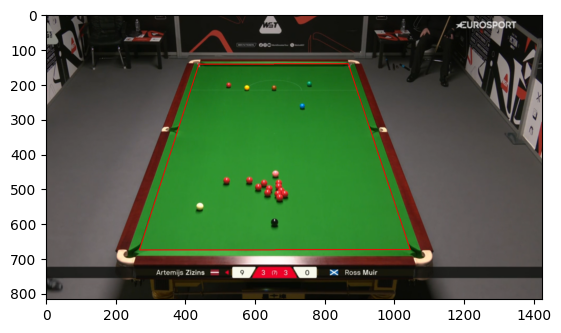

In [28]:
plt.imshow(out_img)